<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid and attractors
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
N_nodes = 20
theta = np.pi / 3
centers = np.random.choice(x, size=N_nodes, replace=False)

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

nodes = [gaussian(c, sigma, A) * np.cos(theta) for c in centers]
phi = sum(nodes)


In [2]:
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)

for t in range(300):
    phi = evolve(phi)


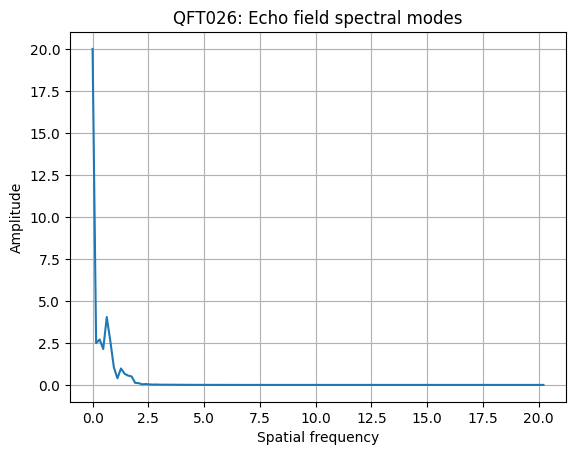

Dominant spatial modes: []


In [3]:
# Spatial FFT
phi_fft = np.fft.fft(phi)
freqs = np.fft.fftfreq(N_grid, d=(x[1] - x[0]))
amplitudes = np.abs(phi_fft)

plt.plot(freqs[:N_grid//2], amplitudes[:N_grid//2])
plt.xlabel("Spatial frequency")
plt.ylabel("Amplitude")
plt.title("QFT026: Echo field spectral modes")
plt.grid(True)
plt.show()

# Detect dominant modes
from scipy.signal import find_peaks
peaks, _ = find_peaks(amplitudes[:N_grid//2], prominence=5)
print("Dominant spatial modes:", freqs[peaks])
